# This notebook documents the UQ of the Amaducci 2019 $^{235}$U(n,f)/$^{6}$Li(n,$\alpha$) cs experimental data for the Standards. (Data release: LA-UR-25-32229)

- Roberto Capote said to re-bin it to the GMA grid in the energy range outside of the Standards (RRR), but the binning is already rather coarse so that above 2 keV in most GMA bins, only one data point can be found. So re-binning does not make sense there.
- I will re-bin data until 1.7 keV and then leave the original data in. This was verified with Roberto Capote.
- They did important corrections for background, impurities, detector efficiency, multiple scattering and attenuation, and neutron flux differences between the different samples. I think a well-done measurementl.
- The data are shape data as they were normalizated to the integral of the cross section from 7.8–11.0eV. Due to that, I ignore all normalization uncertainties.
- I do not add impurity uncertainties as the sample is very pure.

In [3]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid, interp, concatenate, delete
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
homedir = os.getcwd() +'/'

In [9]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [49]:
import Class_nfcs_legacy as Cnf
reload(Cnf)

<module 'Class_nfcs_legacy' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py'>

In [13]:
datafile = '../Data/U-235/n-092-U-235_nfcs_ENDFBVIII0.dat'
alldata  = loadtxt(datafile)
EVIII1U5   = alldata[:,0] # MeV
csVIII1U5  = alldata[:,1] # b

datafile = '../Data/Li-6/n-003-Li-006_ntcs_ENDFBVII1.dat'
alldata  = loadtxt(datafile)
EVIII1Li6   = alldata[:,0]*1.0e-6 # MeV
csVIII1Li6  = alldata[:,1] # b

ratio_U5Li6 = csVIII1U5/interp(EVIII1U5,EVIII1Li6,csVIII1Li6)

In [19]:
datafile = homedir+'Amaducci2019.txt'
alldata  = loadtxt(datafile)

Einc  = (alldata[:,0]*0.5 + alldata[:,1]*0.5)*1.0e-6 # MeV
Einclow  = alldata[:,0]*1.0e-6 # MeV
Einchigh = alldata[:,1]*1.0e-6 # MeV
edgesE      = zeros(len(Einc) + 1)
edgesE[:-1] = Einclow
edgesE[-1]  = Einchigh[-1]

Einc = alldata[:,0]*.5e-6 + alldata[:,1]*.5e-6
ratio = alldata[:,2] # shape U-235(n,f)/Li-6(n,t).
statuncU235 = alldata[:,4] 
statuncLi6 = alldata[:,5]
deteffunc = alldata[:,6]

Statunc = sqrt(statuncU235*statuncU235 + statuncLi6*statuncLi6)

#normLi = 0.37 #% Counting statistics of 235U(n,f)/6Li(n,a) in the 7.8-11 eV cross section integral (0.37%).
#normUratiotoLi = 1.32 #% 235U(n,f)/6Li(n,a) ratio at 7.8-11 eV.
# I wonder if we should treat them as shape data. Yes, they are treated as shape data and hence their normalization uncertainties
# are ignored.

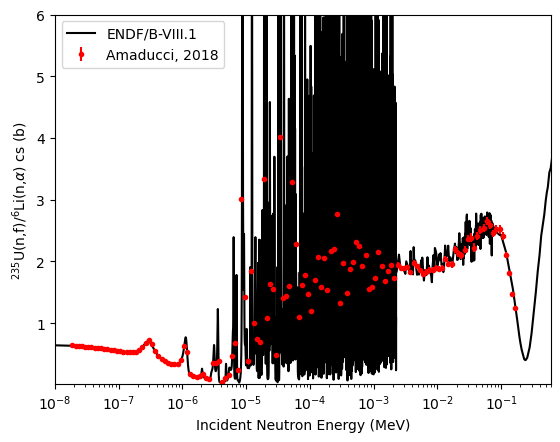

In [21]:
plt.figure(1)
plt.xlim([1.0e-8,0.6])
plt.ylim([0.01,6.0])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel(r'$^{235}$U(n,f)/$^{6}$Li(n,$\alpha$) cs (b)')
plt.semilogx(EVIII1U5,ratio_U5Li6,'k',zorder=1,label="ENDF/B-VIII.1")
plt.errorbar(Einc,ratio,statuncU235*ratio/100.0,fmt='r.',label="Amaducci, 2018",zorder=2)
plt.legend()

Text(0, 0.5, 'Cross Section (b)')

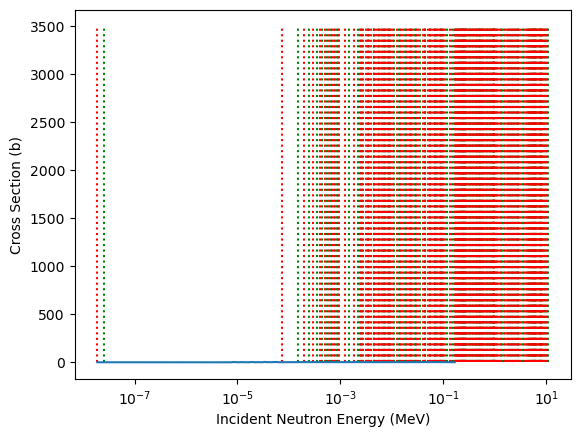

In [29]:
# we need to re-bin the data to a smaller grid. I chose here the GMA grid.
EGMA = loadtxt(homedir+'GMAEnergyGrid_Pu9.txt',comments='#')[:-2,0] # -> these are the mid-points, we want to have.
# But we need the bins for the data to calculate it to.
EGMAbins = zeros(shape(EGMA)[0],dtype = float)
EGMAbins[0] = min(Einc)
for index1 in arange(1,shape(EGMA)[0]):
    EGMAbins[index1] = 0.5*(EGMA[index1]+EGMA[index1-1])
plt.vlines(x=EGMA, ymin=0, ymax=3500, colors='g', linestyles=':', label='Vertical Lines')
plt.vlines(x=EGMAbins, ymin=0, ymax=3500, colors='r', linestyles=':', label='Vertical Lines')
plt.semilogx(Einc,ratio)
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Cross Section (b)')

# I don't worry here about the highest bin as the experimental data end at 10 MeV.

In [33]:
BinnedData = zeros(shape(EGMA)[0],dtype = float)
BinnedStatUnc = zeros(shape(EGMA)[0],dtype = float)

count1 = 0
for index1 in arange(0,shape(EGMA)[0]):
    for index2 in arange(count1,shape(Einc)[0]):
        if Einc[index2] > EGMAbins[index1]:
            break
    count2 = index2
    if shape(ratio[count1:count2])[0] > 0:
        BinnedData[index1] = sum(ratio[count1:count2])/float(shape(ratio[count1:count2])[0])

        for index2 in arange(count1,count2):
            BinnedStatUnc[index1] = BinnedStatUnc[index1] + 1/(Statunc[index1]**2.0)
        BinnedStatUnc[index1] = sqrt(1.0/BinnedStatUnc[index1])
    count1 = count2
#print(BinnedData)

Text(0, 0.5, 'Relative Uncertainty (%)')

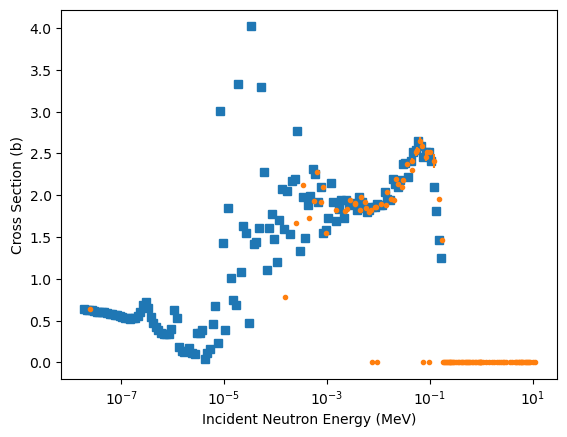

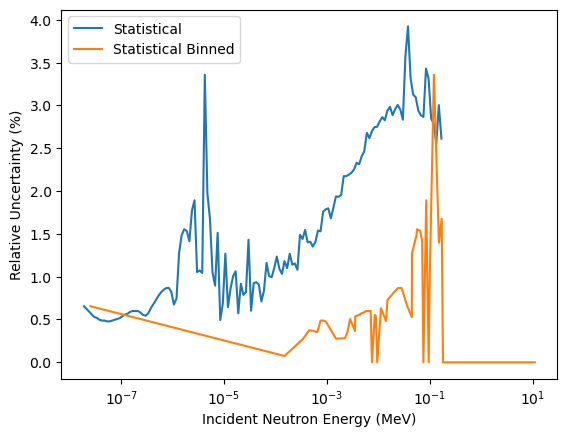

In [35]:
plt.semilogx(Einc,ratio,'s')
plt.errorbar(EGMA,BinnedData,yerr=BinnedStatUnc*BinnedData/100.0,fmt='.')
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Cross Section (b)')

plt.figure(2)
plt.semilogx(Einc,Statunc)
plt.semilogx(EGMA,BinnedStatUnc)
plt.legend(['Statistical','Statistical Binned','Systematic'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [37]:
# Here I combine data that is re-binned from the lowest energies to 1.7 keV, I will eliminate the 2nd point as the binning is unphysical.

# Define the threshold
threshold = 0.0017  # MeV

# Extract data from binned dataset with E > threshold:
mask_binned = EGMA < threshold
E_binned = EGMA[mask_binned]
ratio_binned = BinnedData[mask_binned]
Statunc_binned = BinnedStatUnc[mask_binned]

# Extract data from datasetorg (x <= threshold)
mask_org = Einc >= threshold
E_org = Einc[mask_org]
ratio_org = ratio[mask_org]
Statunc_org = Statunc[mask_org]

# Combine the datasets
E_combined = concatenate([E_binned, E_org])
ratio_combined = concatenate([ratio_binned, ratio_org])
Statunc_combined = concatenate([Statunc_binned, Statunc_org])


# Drop the second value (index 1) because the cross section changes too rapdily to make sense to include the average value.
E_combined = delete(E_combined, 1)
ratio_combined = delete(ratio_combined, 1)
Statunc_combined = delete(Statunc_combined, 1)

Text(0, 0.5, 'Relative Uncertainty (%)')

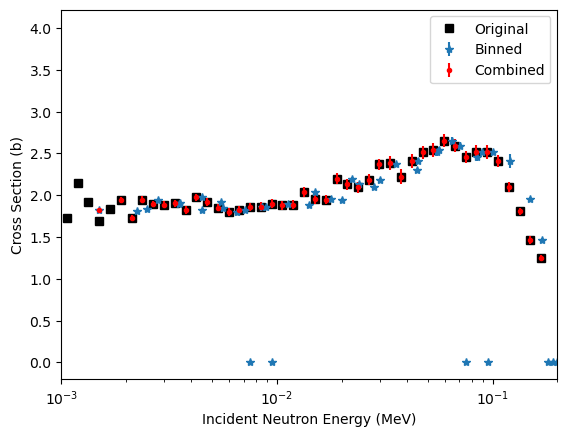

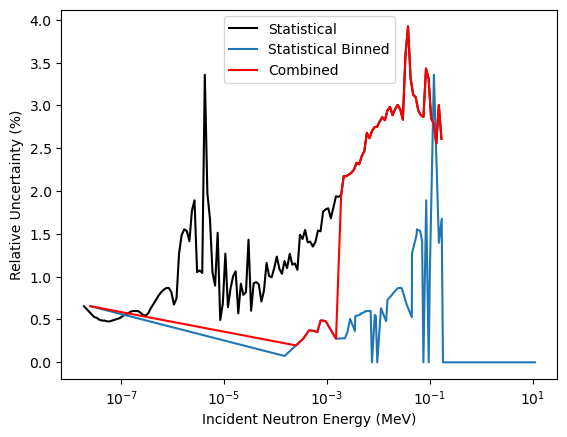

In [39]:
#plt.ylim([1.,3.4])
plt.xlim([0.001,0.2])
plt.semilogx(Einc,ratio,'ks')
plt.errorbar(EGMA,BinnedData,yerr=BinnedStatUnc*BinnedData/100.0,fmt='*')
plt.errorbar(E_combined,ratio_combined,yerr=Statunc_combined*ratio_combined/100.0,fmt='r.')
plt.xlabel('Incident Neutron Energy (MeV)')
plt.legend(['Original','Binned','Combined'])
plt.ylabel('Cross Section (b)')

plt.figure(2)
plt.semilogx(Einc,Statunc,'k')
plt.semilogx(EGMA,BinnedStatUnc)
plt.semilogx(E_combined,Statunc_combined,'r')
plt.legend(['Statistical','Statistical Binned','Combined'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [41]:
#variationaluncB  = 1.0*ones(nodata,dtype=float) #%, they made some cuts in the data, and then varied the cut which then gives these uncertainties. This is a det eff. unc.
#variationaluncLi = 0.3*ones(nodata,dtype=float) #%, they made some cuts in the data, and then varied the cut which then gives these uncertainties. This is a det eff. unc.
# I took the variational uncertainties out after Allan pointed out they are considered by the authors normalization uncertainties.

# These uncertainties should remain.
nodata = shape(E_combined)[0] #,Statunc_combined
attenuation = zeros(nodata,dtype=float) #% beam attenuation at low energies.
forwardangle = zeros(nodata,dtype=float) #% above 1 keV.

Eunc = zeros(nodata,dtype=float)

for index in arange(0,nodata):
    if E_combined[index] < 0.001: 
        attenuation[index ] = 0.3
    elif E_combined[index] > 0.001: 
        forwardangle[index] = 1.0

# leave in.
backgroundunc = 0.2*ones(nodata,dtype=float) #10% of the background correction. A run was performed with the real sam- ples replaced by the dummy ones, and the background at all the neutron energies was found well below 10−3 for
# the lithium and uranium samples with respect to the re- action count rates, therefore it was neglected in the anal- ysis. For the boron samples we found that above 1keV neutron energy this background contributed ≈ 2% and was subtracted. 

Text(0, 0.5, 'Relative Uncertainty (%)')

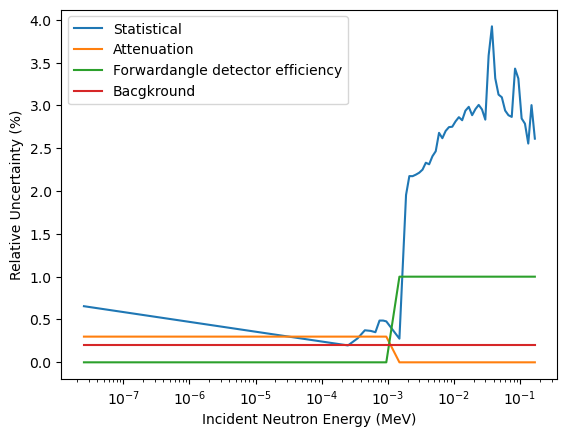

In [43]:
plt.semilogx(E_combined,Statunc_combined,label='Statistical')
plt.semilogx(E_combined,attenuation,label="Attenuation")
plt.semilogx(E_combined,forwardangle,label="Forwardangle detector efficiency")
plt.semilogx(E_combined,backgroundunc,label="Bacgkround")
plt.legend()
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [45]:
features = {
  "Author": ["S.Amaducci", "L.Cosentino", "M.Barbagallo", "N.Colonna", "A.Mengoni", "C.Massimi", "S.Lo Meo", "P.Finocchiaro", "and 80+ n_TOF Collaboration members"],
  "Year": "2019",
  "Absolute": "n",
  "GMAnumber": "6014",
  "MonitorReaction": "(3-LI-6(N,T)2-HE-4,,SIG)",
  "EXFORnumber": ["23453002"],
  "CorrelatedData": ["23453003", "23453004", "23453005"],
  "Facility": ["SYNCY", "2ZZZCER"],
  "Institute": ["2ITYLNS", "2ITYBAU", "2ITYBOL", "2ITYUBO", "2ZZZCER", "3POLLOU", "2FR PAR", "2AUSTHV", "2FR SAC", "2SPNPCM", "3CZRCHU", "2UK MAN", "3CROZAG", "2UK YRK", "2SPNSAU", "2SPNUPC", "2SPNSEU", "2SPNVAL", "2SWTPSI", "2PRTLFE", "4ZZZDUB", "2GERFRK", "3RUMBUC", "2JPNJAE", "2ZZZGEL", "2GERKFK", "2GRCTUA", "2UK EDG", "2GERPTB", "2ITYPAD", "2ITYTRI", "2ITYCAT", "2GRCIOA", "2AUSVIE", "2SPNGRU", "2SWTBAS", "2UK HFS", "3INDTRM", "3AULCBR"],
  "Isotope": "U-235",
  "quantity": "cs ratio",
  "reaction": "n,f",
  "MeasurementType": "TOF",
  "ConcernEXFOR": "None",
  "AcceptedVsRejected": "accepted",
  "BackgroundCorrected": "y",
  "AlphaBackground": "y",
  "CosmicRaysBackground": "N/A",
  "GammaBackground": "y",
  "RandomCoincidenceBackground": "y",
  "ShadowBarBackground": "N/A",
  "WrapAroundBackground": "N/A",
  "SampleGammaRaySelfabsorption": "N/A",
  "SampleFoilGeometryCorrection": "N/A",
  "SampleNeutronFluxCorrection": "y",
  "SampleNeutronFluxContaminationCorrection": "unknown",
  "MonitorGammaRaySelfabsorption": "N/A",
  "MonitorFoilGeometryCorrection": "N/A",
  "MonitorNeutronFluxCorrection": "y",
  "MonitorFluxContaminationCorrection": "unknown",
  "NeutronMultipleScatteringSampleBackingCorrected": "y",
  "NeutronMultipleScatteringSurroundingCorrected": "y",
  "NeutronAttenuationSampleBackingCorrected": "y",
  "NeutronAttenuationSurroundingCorrected": "y",
  "EfficiencyCorrected": "y",
  "StoppingPowerCorrected": "unknown",
  "SampleRoughnessCorrected": "unknown",
  "SampleDecayCorrected": "unknown",
  "FissionFragmentAbsorptioninSampleCorrected": "y",
  "SignalPulsePileupCorrected": "y",
  "DeadtimeCorrected": "y",
  "AngularDistributionFissionFragmentsCorrected": "y",
  "ImpuritiesCorrected": "y",
  "SelfShieldingCorrected": "y",#check
  "ForwardBoostCorrected": "y",
  "MissingCorrections": ["SampleRoughnessCorrected"],
  
  "FissionDetector": {#
    "Type": "SI",
    "Number": 6,
    "ParticleDetected": ["FF", "triton", "alpha"],
    "Efficiency": 96.8,
    "EfficiencyMethod": ["Monte Carlo simulation (GEANT4)", "constant vs. neutron energy for fission fragments", "ratio to 6Li(n,t) standard", "corrected for angular acceptance and geometry"],
    "FFAbsorptionAngularDistributionMethod": ["MC"],
    "AngularAcceptanceofFF": 360.0,
    "Gas": {
      "Type": "N/A",
      "Purity": "N/A",
      "Pressure": "N/A",
      "Pressure_unit": "N/A"
    },
    "Size": {
      "geometry": "planar",
      "dimensions": [50, 50, 200],
      "dimensions_unit": ["mm", "mm", "mum"]
    },
    "NoPhotomultipliers": "N/A",
    "Weight": "unknown",
    "StructuralMaterial": ["Si", "Al"],
    "ReferenceDetector": "SI",
    "DistanceDetectorSample": "unknown",
    "DistanceDetectorSample_unit": "N/A",
    "CountingTime": "N/A",
    "CountingTime_unit": "N/A"
  },
  
  "NeutronDetector": {
    "Type": "SI",
    "Number": 6,
    "ParticleDetected": "triton",
    "Efficiency": 96.8,
    "ResponseDeterminationMethod": ["Monte Carlo simulation (GEANT4)", "constant vs. neutron energy for fission fragments", "ratio to 6Li(n,t) standard", "corrected for angular acceptance and geometry"],
    "EfficiencyRatioDeterminationMethod": ["Monte Carlo simulation (GEANT4)", "constant vs. neutron energy for fission fragments", "ratio to 6Li(n,t) standard", "corrected for angular acceptance and geometry"],
    "CoincidenceEfficiencyMethods": {
      "Measured": "N/A",
      "ReferenceDetector": "N/A",
      "MonitorReaction": "N/A",
      "Assumption": "N/A"
    },
    "Angle": 360.0,
    "Angle_unit": "deg",
    "Gas": {
      "Type": "N/A",
      "Purity": "N/A",
      "Pressure": "N/A"
    },
    "Size": {
      "geometry": "planar",
      "dimensions": [50, 50, 200],
      "dimensions_unit": ["mm", "mm", "mum"]
    },
    "NoPhotomultipliers": "N/A",
    "Weight": "unknown",
    "StructuralMaterial": ["Si", "Al"],
    "ReferenceDetector": "SI",
    "DistanceDetectorSample": "unknown",
    "DistanceDetectorSample_unit": "N/A",
    "CountingTime": "N/A",
    "CountingTime_unit": "N/A"
  },
  
  "Shielding": {
    "Material": "Aluminum (beamline), concrete",
    "Size": {
      "Geometry": "unknown",
      "Thickness": "unknown",
      "Thickness_unit": "N/A"
    },
    "DistanceFromTarget": "surrounding experimental area",
    "Purpose": "reduce gamma and scattered neutron background"
  },
  
  "Sample": {
    "Activity": "low (from U-235 natural decay)",
    "Activity_unit": "N/A",
    "Reused": "no",
    "Number": 6,
    "Form": "metal",
    "Mass": "unknown",
    "Mass_unit": "N/A",
    "Diameter": 40.0,
    "Diameter_unit": "mm",
    "Thickness": 0.145,
    "Thickness_unit": "mum",
    "Homogenity": "unknown",
    "Contaminants": {
      "U-234": "<0.0001%",
      "U-235": 99.999,
      "U-236": "<0.0001%",
      "U-238": "<0.001%"
    },
    "BackingMaterial": "Al",
    "BackingDiameter": 40.0,
    "Diameter_unit": "mm",
    "BackingThickness": 250.0,
    "BackingThicknessUnit": "mum",
    "DecayDeterminationMethod": "N/A",
    "CoolingTime": "N/A",
    "Configuration": "parallel",
    "Fabrication": "molecular plating",
    "ImpurityDetermination": "unknown",
    "NumberOfAtomsInSampleDeterminationTechnique": "N/A",
    "AngletoBeam": 0.0,
    "AngletoBeam_unit": "deg"
  },
  
  "BackgroundMethods": {
    "General": ["beam-off subtraction", "PhD", "timing correlation with TOF signal","MC (GEANT4, simulations for ambient neutron capture)"],
    "Wraparound": ["N/A"],
    "alpha": ["PhD", "energy-dependent thresholding to discriminate from natural U-235 decay"],
    "Gamma": ["PhD","MC (GEANT4, for capture gamma-rays from ambient materials)"],
    "RandomCoincidence": "timing correlation with TOF signal",
    "CosmicRays": ["N/A"]
  },
  
  "NeutronMultipleScatteringMethods": {
    "InSample": ["MC (GEANT4)"],
    "Surrounding": ["MC (GEANT4)"]
  },
  
  "NeutronAttenuationMethods": {
    "InSample": ["MC (GEANT4)"],
    "Surrounding": ["MC (GEANT4)"]
  },
  
  "GammaRaySelfabsorptionMethods": {
    "InSample": "N/A",
    "InMonitor": "N/A"
  },
  
  "NeutronFluxCorretionMethods": {
    "InSample": "normalization to saturated resonances in 7.8-11 eV range using ENDF/B-VIII.0",
    "InMonitor": "normalization to saturated resonances in 7.8-11 eV range using ENDF/B-VIII.0"
  },
  
  "DeadtimeDeterminationMethod": "live-time normalization from DAQ system",
  "EnergyDetermination": "TOF",
  
  "NeutronBeam": {
    "Facility": ["SYNCY", "2ZZZCER"],
    "PulseWidth": 7.0,
    "PulseWidthUnit": "ns",
    "NeutronProducingReaction": ["p + Pb → n (spallation)", "20 GeV/c protons on Pb target"],
    "Target": "Pb (water-cooled)",
    "EnergySpread": "thermal to 170 keV (measurement range: 0.0178 eV to 178 keV)",
    "Monitor": "(3-LI-6(N,T)2-HE-4,,SIG)",
    "Diameter": "unknown",
    "Diameter_unit": "N/A",
    "TimeGateOpen": "unknown",
    "TimeGateOpen_unit": "N/A",
    "TOFLength": {
      "Value": 183.49,
      "Unit": "m",
      "Unc": 0.02,
      "Unit_Unc": "m"
    },
    "trsl": {
      "Value": 1.7,
      "Unit": "ns",
      "Measure": "1-sigma"
    },
    "t0Determination": "gamma flash",
    "IrradiationTime": "continuous",
    "IrradiationTime_unit": "N/A"
  }
}

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
{'isotope': 'Li-6', 'quantity': 'cs', 'reaction': 'n,t', 'identifier': 'ENDF/B-VII.1'}
deriv_nucdata: [-9.49908282e+05 -3.60655929e+05  1.37401113e+05 -1.85670771e+06
  3.17157811e+05 -3.51818364e+05 -1.13233123e+06  5.10777917e+05
 -1.00175420e+06  2.69139917e+05 -5.91835074e+05  5.35423895e+05
  1.36266888e+03 -3.00801806e+02 -3.64408583e+02 -3.97829879e+02
  3.74552499e+03  4.48719449e+03 -7.89615144e+02  7.05462324e+02
 -1.08700731e+03 -6.18767435e+01 -2.70943611e+02  8.

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/BasicPhysicsFunctions.py:230: RuntimeWarning: divide by zero encountered in scalar divide
  data_derivative[index] = (data[index+1]-data[index])/(lattice[1+index]-lattice[index])
/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py:2114: UserWarning: Warning: Minimum outgoing energy of experiment smaller than that of the reference data.
  warn(msg)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


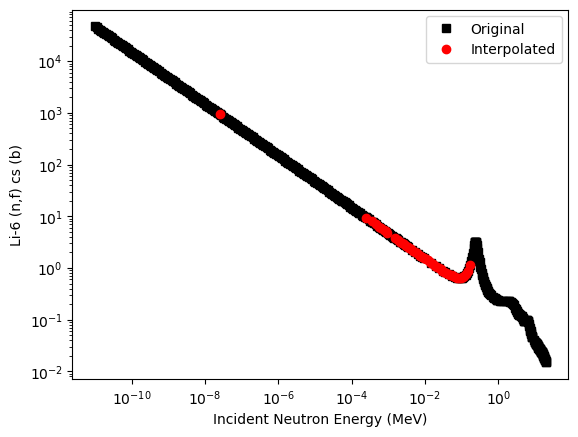

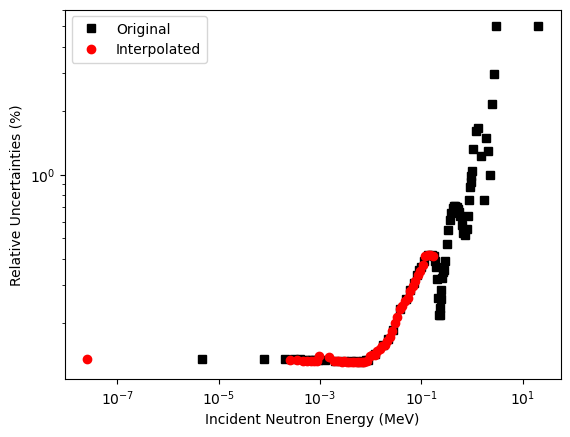

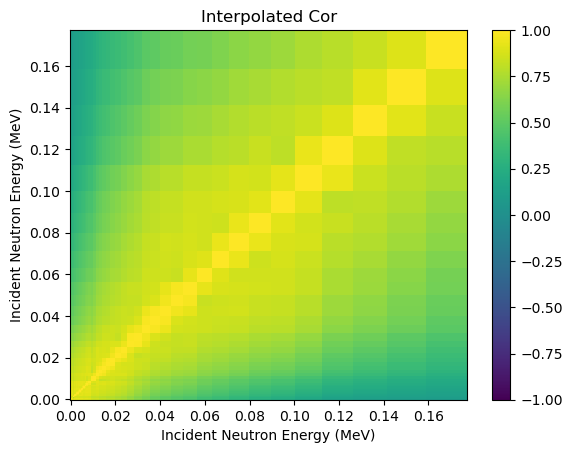

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-235/nfcs_DS6014Amaducci/nfcs_Amaducci2019.xml
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-235/nfcs_DS6014Amaducci/nfcs_Amaducci2019EUCLID.json
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
{'isotope': 'Li-6', 'quantity': 'cs', 'reaction': 'n,t', 'identifier': 'ENDF/B-VII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/U-235/nfcs_DS6014Amaducci/nfcs_Amaducci2019ratiodataEUCLID.json

Output file saved in file: /Users/dneudec

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


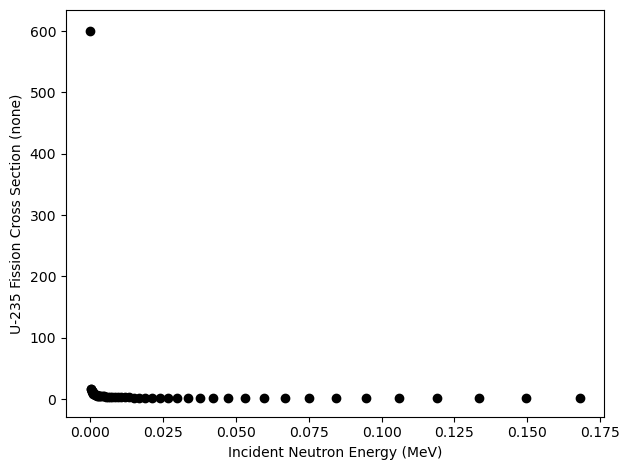

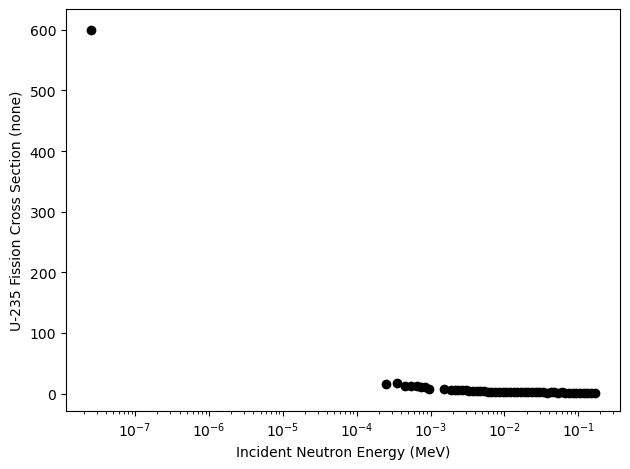

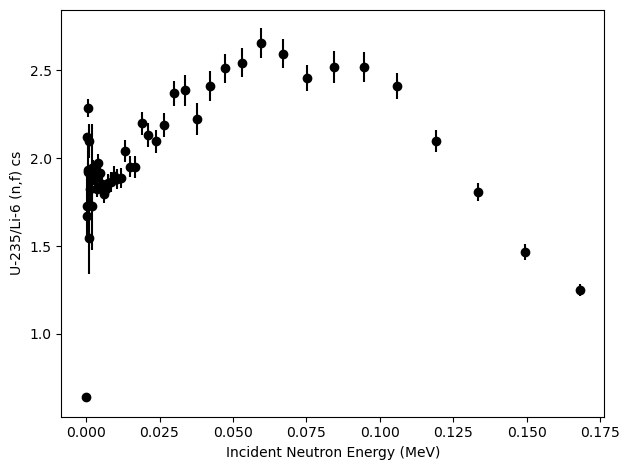

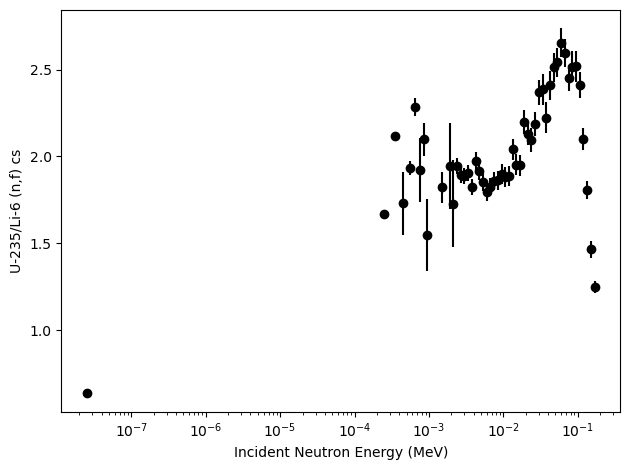

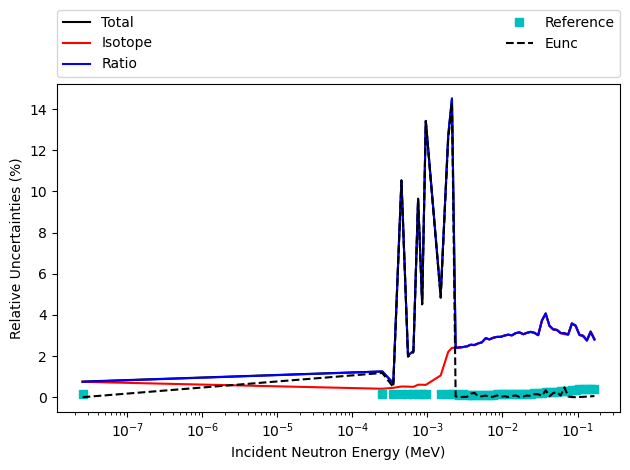

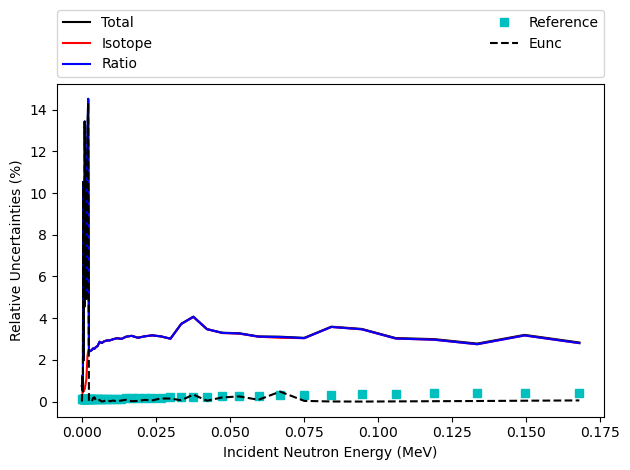

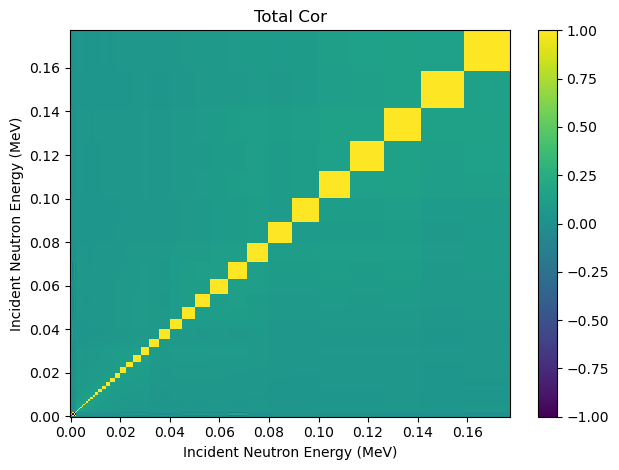

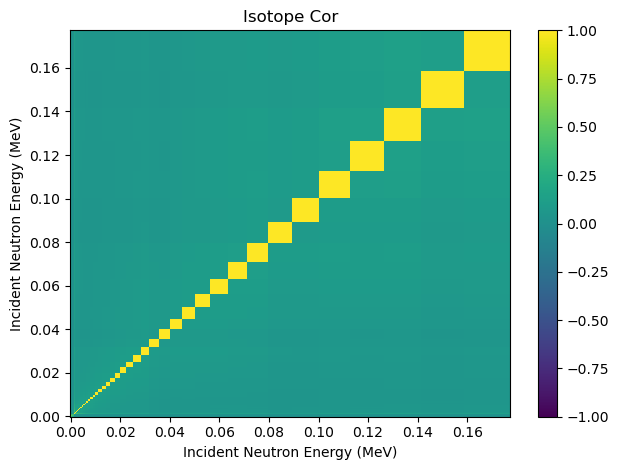

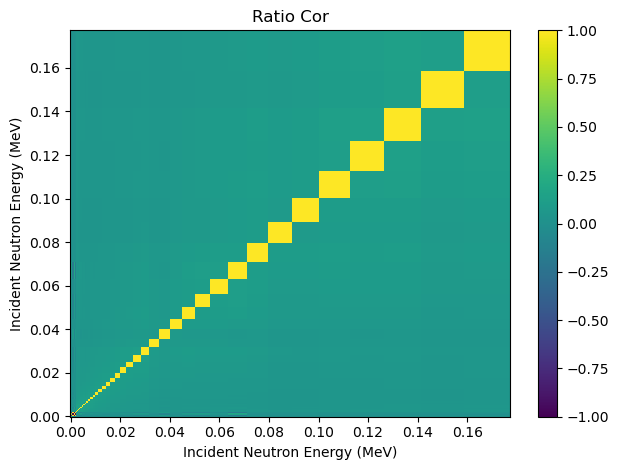

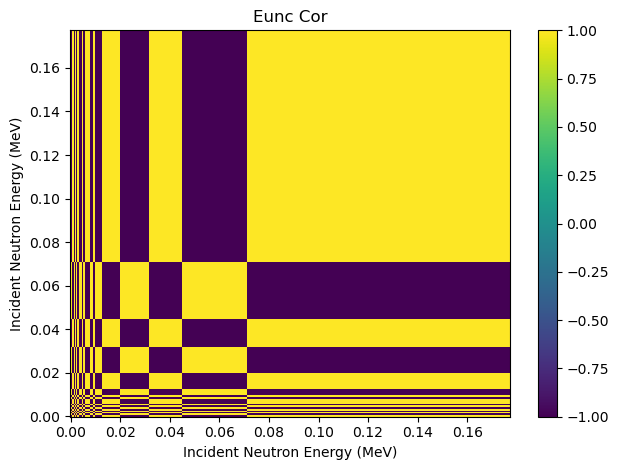

In [51]:
Documentation = """"EXFOR No. = 23453002. 
Journal article = European Physical Journal A: Hadrons and Nuclei, Vol.55, p.120 (2019), Germany. \
- Roberto said to re-bin it to the GMA grid in the energy range outside of the Standards (RRR), but the binning is already rather coarse so that above 2 keV in most GMA bins, only one data point can be found. So re-binning does not make sense there.
- I will re-bin data until 1.7 keV and then leave the original data in. This was verified with Roberto.
- They did important corrections for background, impurities, detector efficiency, multiple scattering and attenuation, and neutron flux differences between the different samples. I think a well-done measurementl.
- The data are shape data as they were normalizated to the integral of the cross section from 7.8–11.0eV. Due to that, I ignore all normalization uncertainties.
- I do not add impurity uncertainties as the sample is very pure."""

general_info = {'name': 'Amaducci2019', 'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'nfcs_Amaducci2019.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

trsl = features['NeutronBeam']['trsl']['Value']
deltat_vsTOF = trsl*1.0e-9/(features['NeutronBeam']['TOFLength']['Value']) # assuming FWHM, DON'T CONVERT TO 1-SIGMA. THIS MUST BE FULL-WIDTH HALF-MAXIMUM!!!
nmass = 1.67492735174e-27 # kg
Energyconversionfactor = 1.60217653e-13
Ersl = 100.0*sqrt(8)*sqrt(E_combined*Energyconversionfactor)*deltat_vsTOF/sqrt(nmass)

resolution = {
              'chw_edges': edgesE,
              'chw_edges_unit':'MeV',
              'tof_length':features['NeutronBeam']['TOFLength']['Value'],
              'tof_length_unit':features['NeutronBeam']['TOFLength']['Unit'],
              'tof_length_unc':features['NeutronBeam']['TOFLength']['Unc'],
              'tof_length_unc':features['NeutronBeam']['TOFLength']['Unit_Unc'],
              'energy_resolution': Ersl*E_combined/100.0,
              'energy_resolution_unit': 'MeV'
              }


einc_unc = {'tof_length': {'value':  features['NeutronBeam']['TOFLength']['Value'] ,\
                           'value_unit': features['NeutronBeam']['TOFLength']['Unit'], \
                           'unc': features['NeutronBeam']['TOFLength']['Unc'], \
                           'unc_unit': features['NeutronBeam']['TOFLength']['Unit_Unc']},\
            'en_err' : {'enerr_unc': array(Ersl*0.2/2.355),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0','resolution':resolution}


reference = {'isotope': 'Li-6','quantity': 'cs', 'reaction': 'n,t','identifier':'ENDF/B-VII.1'}

unc_iso = {'einc_unc': einc_unc,\
           'values':array([Statunc_combined,attenuation,forwardangle,backgroundunc]).transpose(),\
           'units':['%','%'],\
           'type':['Diagonal','Gaussian','Gaussian','Gaussian'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,1.0]}}

data = {'einc': array(E_combined), 'einc_unit': 'MeV', 'values':array(ratio_combined), 'values_unit': "none" }

DS6014_nfcs = Cnf.nfcs_cleanratioshape(general_info,data,unc_iso,reference,features)

Text(0, 0.5, 'Relative Uncertainty (%)')

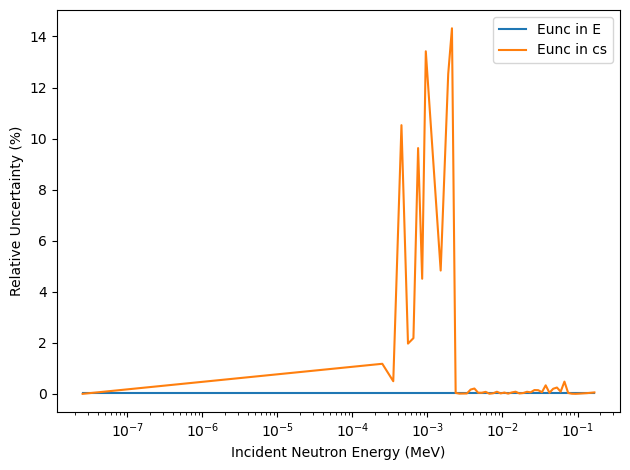

In [55]:
# get energy uncertainties in energy
dim = shape(E_combined)[0]
cscov = DS6014_nfcs.cov_eunc
Euncov = zeros([dim,dim],dtype=float)

deriv_nucdata = [-9.49908282e+05,-3.60655929e+05,1.37401113e+05,-1.85670771e+06\
,3.17157811e+05,-3.51818364e+05,-1.13233123e+06,5.10777917e+05\
,-1.00175420e+06,2.69139917e+05,-5.91835074e+05,5.35423895e+05\
,1.36266888e+03,-3.00801806e+02,-3.64408583e+02,-3.97829879e+02\
,3.74552499e+03,4.48719449e+03,-7.89615144e+02,7.05462324e+02\
,-1.08700731e+03,-6.18767435e+01,-2.70943611e+02,8.50695924e+02\
,-1.67875226e+02,4.13952678e+02,6.93904614e+01,-3.93472616e+02\
,-5.07390953e+02,-8.80841574e+01,-1.74174925e+02,3.77267138e+02\
,2.41573090e+02,5.60741292e+02,5.26315138e+02,-2.09169326e+02\
,-9.07102840e+02,-1.12268278e+02,4.86616924e+02,5.44259624e+02\
,1.77458835e+02,8.52169320e+02,-5.08901140e+01,-7.58388085e+00\
,-1.75098552e+00,-9.77469252e+00,-1.55023954e+01,-1.74337242e+01\
,-1.88794158e+01,-1.92374745e+01
]

# energy resolution and uncertainties are so small that I don't record them.

for index1 in arange(0,dim):
    for index2 in arange(0,dim):
        Euncov[index1,index2]=cscov[index1,index2]*\
        ratio_combined[index1]*ratio_combined[index2]/\
        (E_combined[index1]*E_combined[index2]*deriv_nucdata[index1]*deriv_nucdata[index2])

Euncrelunc = sqrt(diag(Euncov))
plt.semilogx(E_combined,Euncrelunc)
plt.semilogx(E_combined,sqrt(diag(cscov)))
plt.legend(['Eunc in E','Eunc in cs'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [57]:
GMAnewnumber = '6014'
year = '2019'
authors = 'Amaducci et al.'
journal = 'EPJA55,120'
dim = nodata
uncertainty_descriptor = \
['UNCERTAINTIES',\
 '3 STATISTICS',
 '4 Beam attenuation','5 Forward and backward emission of 6Li and 10B (det. eff. unc.)','6 Background (10% of correction)',\
 'The data were normalized with respect to each other from 1-10 eV and are thus treated as shape.']
normalizationunc = [0,0.0,0.0,0.0,0.0,\
                    0.0,0.0,0.0,0.0,0.0]
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0:3,:] = zeros([3,3],dtype=float)
abc_components[4,:] = [0.99,0.01,0.5] 
abc_components[5,:] = [0.99,0.01,0.5] 
abc_components[6,:] = [0.99,0.01,0.5] 
abc_components[7:,:] = zeros([4,3],dtype=float)
uncertainties = zeros([dim,10],dtype=float)
uncertainties[:,:4] = array([Statunc_combined,attenuation,forwardangle,backgroundunc]).transpose()

controlnumber = [0,0,9,1,1,1,0,0,0,0,0]
abs_shape = 'shape'
Enrsl = Eunc
Eunc = zeros(dim,dtype=float)

In [61]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)